In [7]:
import matplotlib.pyplot as plt
import numpy as np

import duckdb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect('../capillary.db')
df = con.execute("""
                SELECT id, interpretation, igg, iga, igm
                FROM protein_data p
                 """).df()

con.close()
def classify_level(interpretation, protein):
    for sentence in interpretation.split('.'):
        s = sentence.lower()
        if protein.lower() not in s:
            continue
        if 'lätt förhöjd' in s or 'lätt förhöjda' in s:
            return 'lätt förhöjd'
        if 'förhöjd' in s or 'förhöjda' in s:
            return 'förhöjd'
        if 'lätt sänkt' in s or 'lätt sänkta' in s:
            return 'lätt sänkt'
        if 'sänkt' in s or 'sänkta' in s:
            return 'sänkt'
    return None
for col, protein in [('igg', 'igg'), ('iga', 'iga'), ('igm', 'igm')]:
    df[f'{col}_level'] = df['interpretation'].apply(
        lambda x: classify_level(x, protein) if pd.notna(x) else None
    )
    print(df[f'{col}_level'].value_counts(dropna=False))


igg_level
NaN             148694
förhöjd          13886
lätt förhöjd      4515
sänkt             3213
lätt sänkt        2203
Name: count, dtype: int64
iga_level
NaN             157059
förhöjd           8379
sänkt             3107
lätt sänkt        2066
lätt förhöjd      1900
Name: count, dtype: int64
igm_level
NaN             159956
förhöjd           4391
sänkt             3319
lätt förhöjd      2454
lätt sänkt        2391
Name: count, dtype: int64



IGG
Lätt förhöjd: 4515, Förhöjd: 13886
Lätt sänkt:   2203, Sänkt: 3213


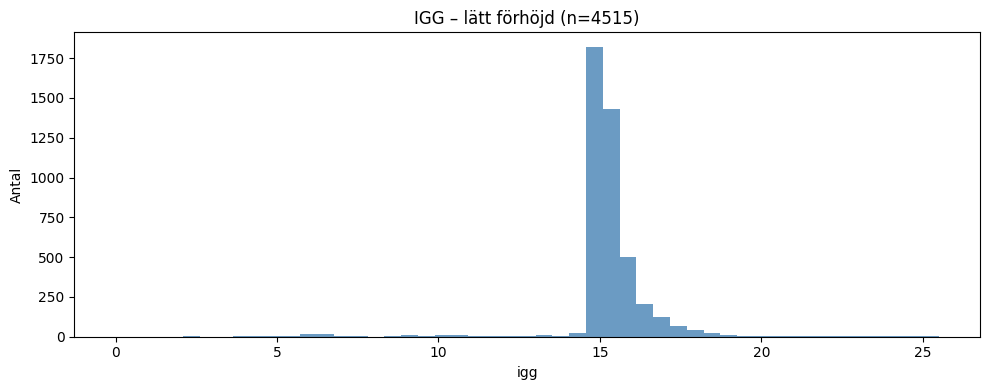

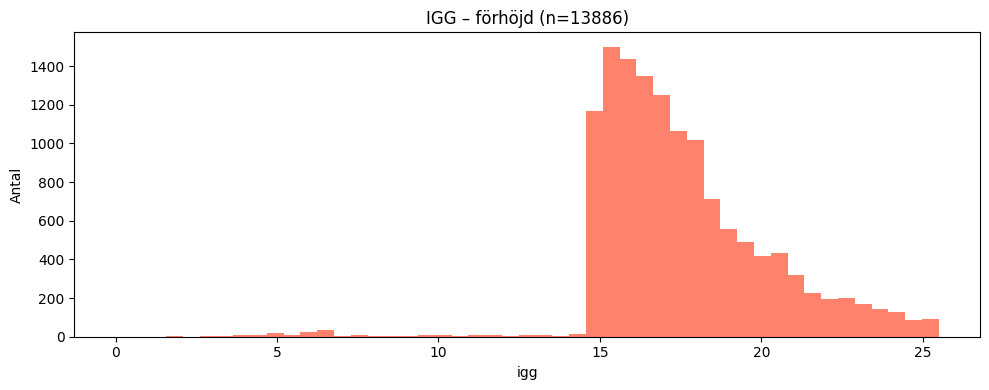

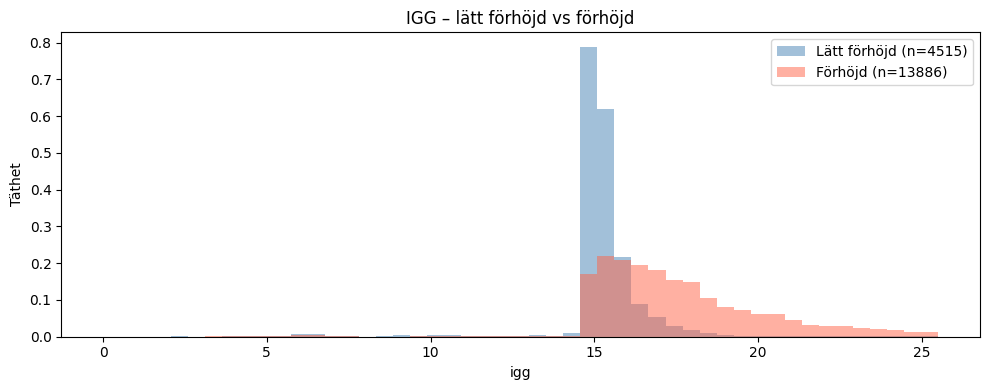

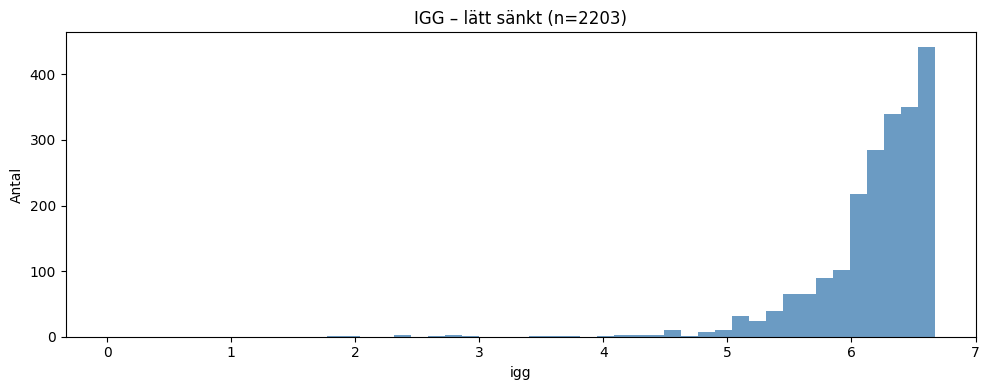

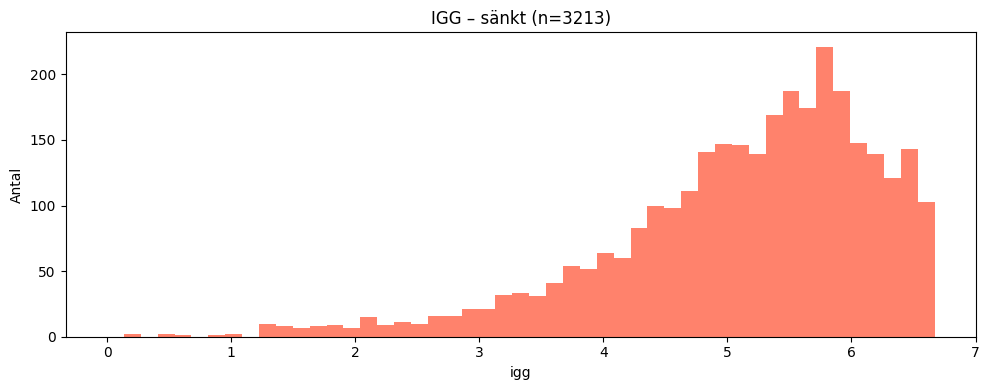

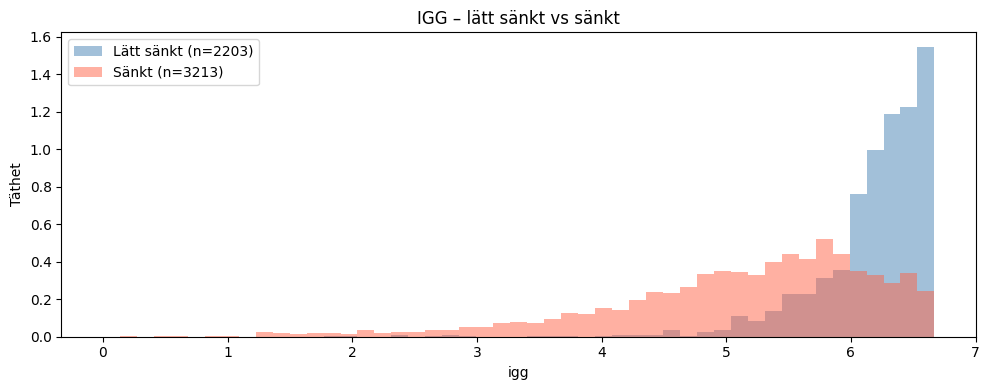


IGA
Lätt förhöjd: 1900, Förhöjd: 8379
Lätt sänkt:   2066, Sänkt: 3107


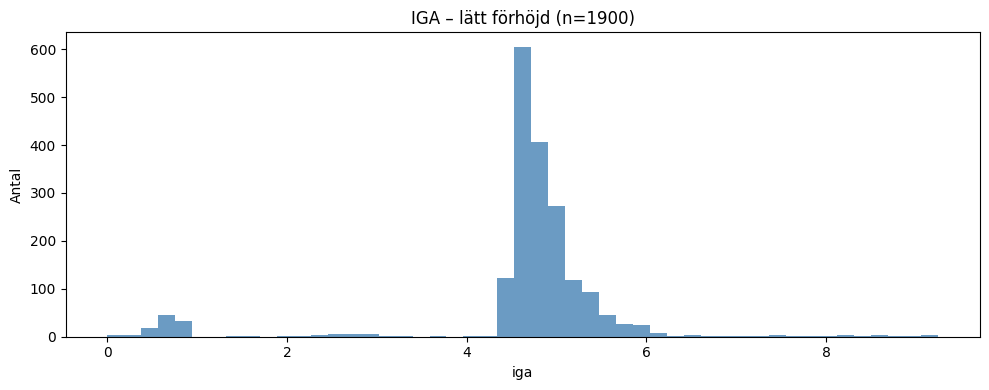

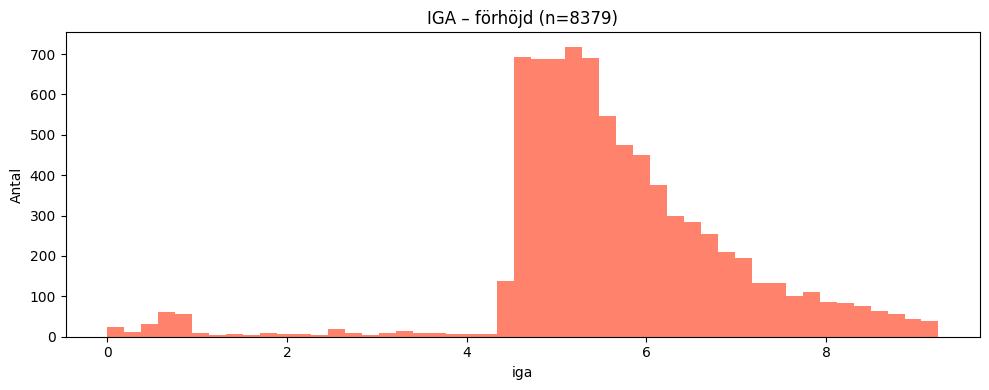

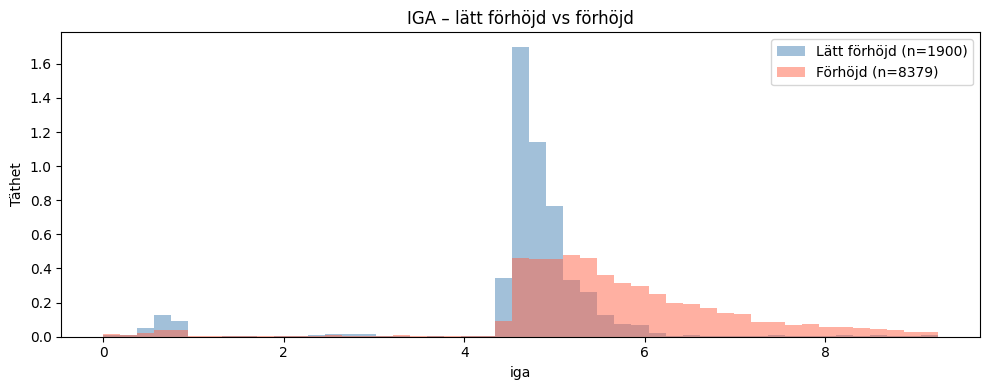

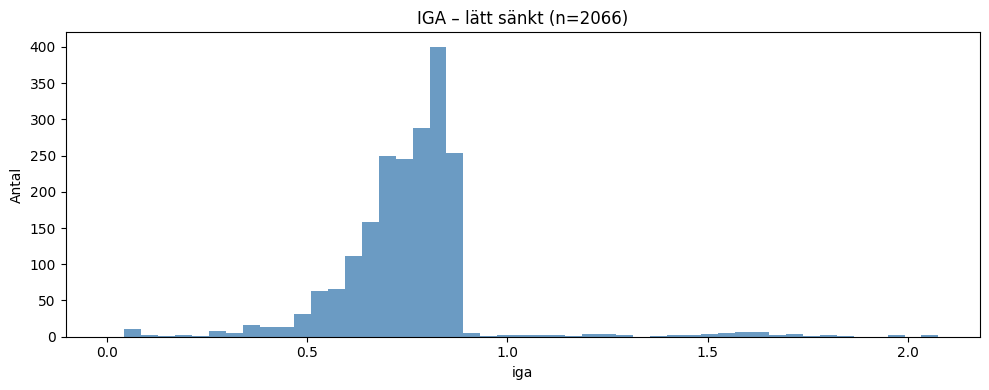

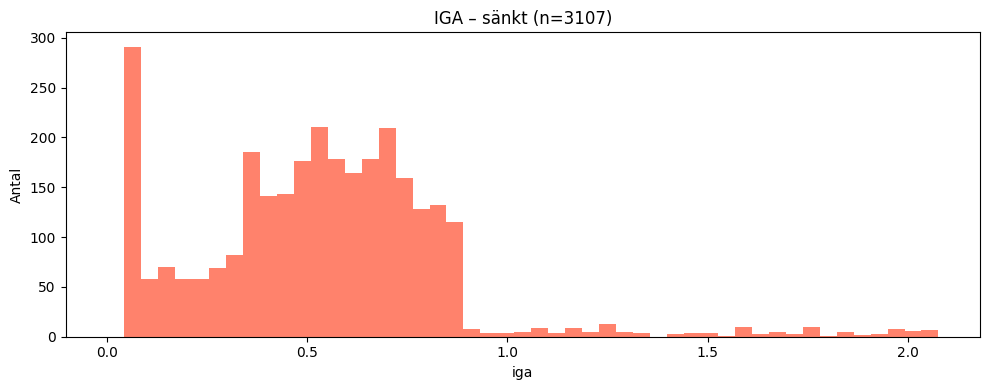

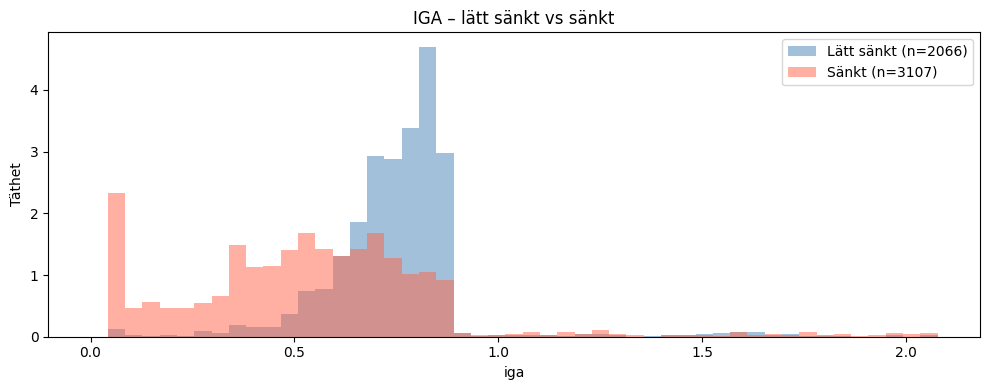


IGM
Lätt förhöjd: 2454, Förhöjd: 4391
Lätt sänkt:   2391, Sänkt: 3319


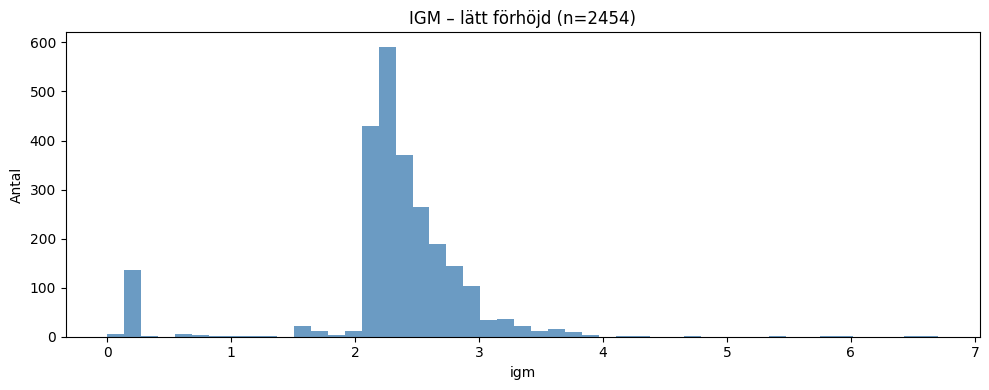

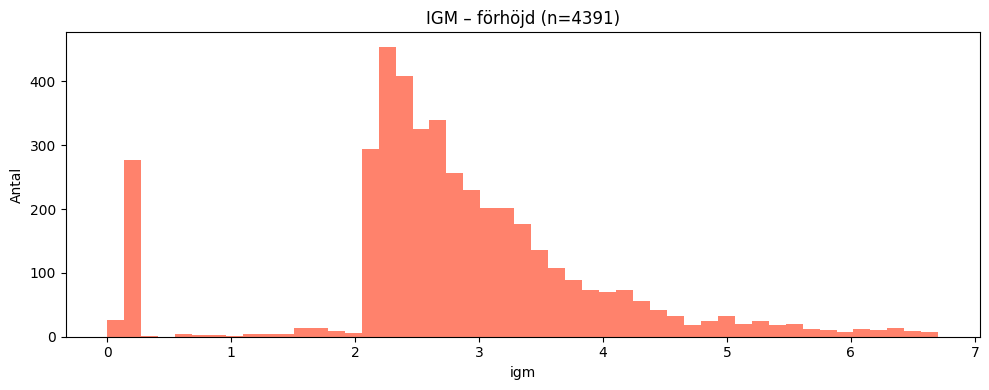

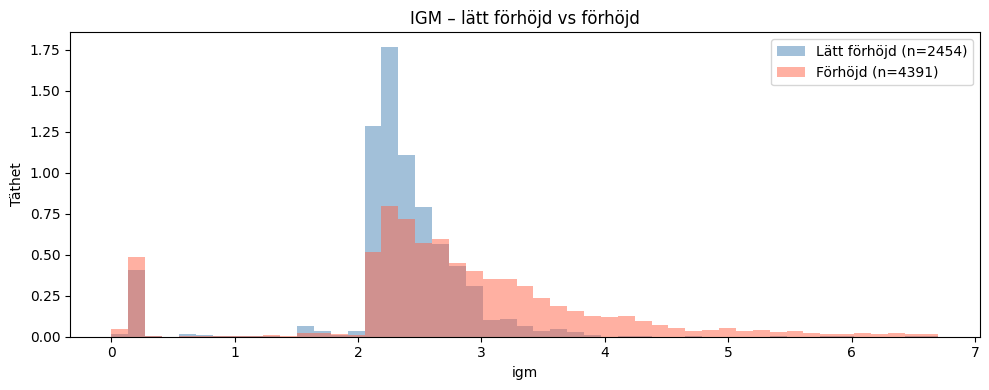

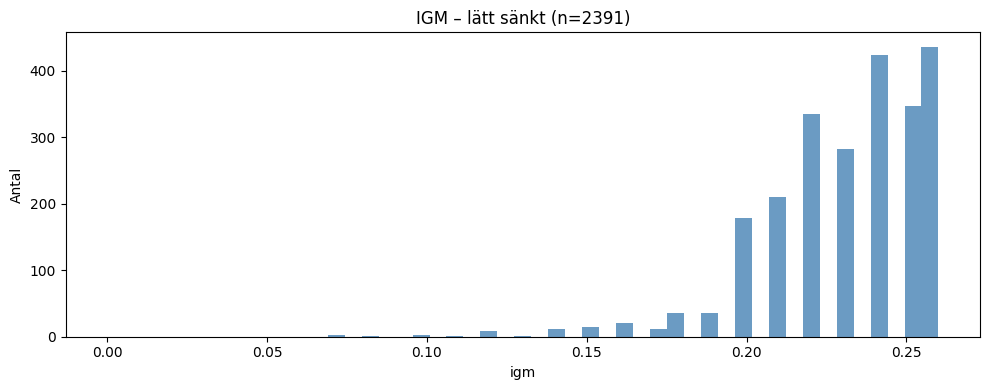

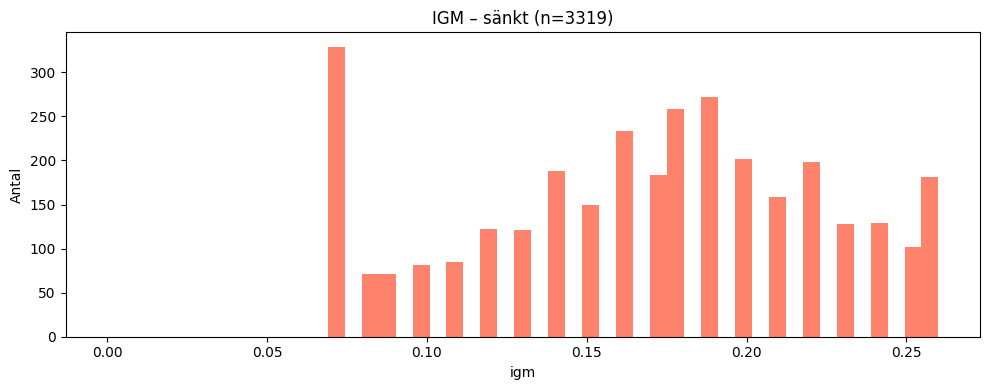

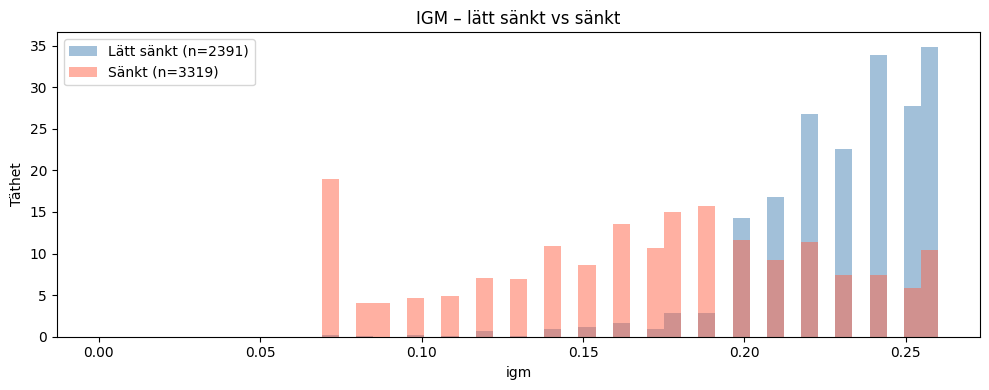

In [9]:

def plot_threshold_analysis(df_lätt_förhöjd, df_förhöjd, df_lätt_sänkt, df_sänkt, col, protein):
    print(f"\n{protein.upper()}")
    print(f"Lätt förhöjd: {len(df_lätt_förhöjd)}, Förhöjd: {len(df_förhöjd)}")
    print(f"Lätt sänkt:   {len(df_lätt_sänkt)}, Sänkt: {len(df_sänkt)}")

    # --- FÖRHÖJD ---
    x_max = max(df_lätt_förhöjd[col].quantile(0.95), df_förhöjd[col].quantile(0.95))
    bins = np.linspace(0, x_max, 50)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df_lätt_förhöjd[col].dropna(), bins=bins, color='steelblue', alpha=0.8)
    ax.set_title(f'{protein.upper()} – lätt förhöjd (n={len(df_lätt_förhöjd)})')
    ax.set_xlabel(col)
    ax.set_ylabel('Antal')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df_förhöjd[col].dropna(), bins=bins, color='tomato', alpha=0.8)
    ax.set_title(f'{protein.upper()} – förhöjd (n={len(df_förhöjd)})')
    ax.set_xlabel(col)
    ax.set_ylabel('Antal')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df_lätt_förhöjd[col].dropna(), bins=bins, alpha=0.5, color='steelblue',
            label=f'Lätt förhöjd (n={len(df_lätt_förhöjd)})', density=True)
    ax.hist(df_förhöjd[col].dropna(), bins=bins, alpha=0.5, color='tomato',
            label=f'Förhöjd (n={len(df_förhöjd)})', density=True)
    ax.set_title(f'{protein.upper()} – lätt förhöjd vs förhöjd')
    ax.set_xlabel(col)
    ax.set_ylabel('Täthet')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- SÄNKT ---
    if len(df_lätt_sänkt) > 0 and len(df_sänkt) > 0:
        x_max = max(df_lätt_sänkt[col].quantile(0.95), df_sänkt[col].quantile(0.95))
        bins = np.linspace(0, x_max, 50)

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(df_lätt_sänkt[col].dropna(), bins=bins, color='steelblue', alpha=0.8)
        ax.set_title(f'{protein.upper()} – lätt sänkt (n={len(df_lätt_sänkt)})')
        ax.set_xlabel(col)
        ax.set_ylabel('Antal')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(df_sänkt[col].dropna(), bins=bins, color='tomato', alpha=0.8)
        ax.set_title(f'{protein.upper()} – sänkt (n={len(df_sänkt)})')
        ax.set_xlabel(col)
        ax.set_ylabel('Antal')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(df_lätt_sänkt[col].dropna(), bins=bins, alpha=0.5, color='steelblue',
                label=f'Lätt sänkt (n={len(df_lätt_sänkt)})', density=True)
        ax.hist(df_sänkt[col].dropna(), bins=bins, alpha=0.5, color='tomato',
                label=f'Sänkt (n={len(df_sänkt)})', density=True)
        ax.set_title(f'{protein.upper()} – lätt sänkt vs sänkt')
        ax.set_xlabel(col)
        ax.set_ylabel('Täthet')
        ax.legend()
        plt.tight_layout()
        plt.show()

for col, protein in [('igg', 'igg'), ('iga', 'iga'), ('igm', 'igm')]:
    df_lätt_förhöjd = df[df[f'{col}_level'] == 'lätt förhöjd']
    df_förhöjd      = df[df[f'{col}_level'] == 'förhöjd']
    df_lätt_sänkt   = df[df[f'{col}_level'] == 'lätt sänkt']
    df_sänkt        = df[df[f'{col}_level'] == 'sänkt']
    
    plot_threshold_analysis(df_lätt_förhöjd, df_förhöjd, df_lätt_sänkt, df_sänkt, col, protein)


## Resultat
Förhöjd IgG > 17.5
Sänkt IgG < 6

Förhöjd IgA > 6
Sänkt IgA < 0.6

Förhöjd IgM > 3
Sänkt IgM < 0.2
